#  Diagnostic Cardiaque par Deep Learning
**EMSI — Module Deep Learning — 2025/2026**  
Encadré par : Mme. HIDILA Zineb

---
### Datasets nécessaires
- **Cleveland** : [Télécharger ici](https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci) → `heart_cleveland_upload.csv`
- **MIT-BIH** : [Télécharger ici](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) → `mitbih_train.csv` + `mitbih_test.csv`

Mets les fichiers dans le **même dossier** que ce notebook.

##  Cellule 0 — Installation des librairies
*(Lance cette cellule une seule fois)*

In [12]:
# Lance cette cellule si les librairies ne sont pas encore installées
# !pip install torch torchvision scikit-learn pandas matplotlib seaborn

##  Cellule 1 — Imports & Configuration

In [13]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── Reproductibilité ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device utilisé : {DEVICE}')

✅ Device utilisé : cuda


## 📊 Cellule 2 — Chargement & Exploration : Cleveland Heart Disease (MLP)

In [14]:
df = pd.read_csv('heart_cleveland_upload.csv')
print('Shape :', df.shape)
df.head()

Shape : (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Distribution cible :
target
0    160
1    137
Name: count, dtype: int64


/tmp/ipykernel_182/485988794.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.select_dtypes(include='number').hist(ax=axes[1], bins=15, figsize=(12,4))


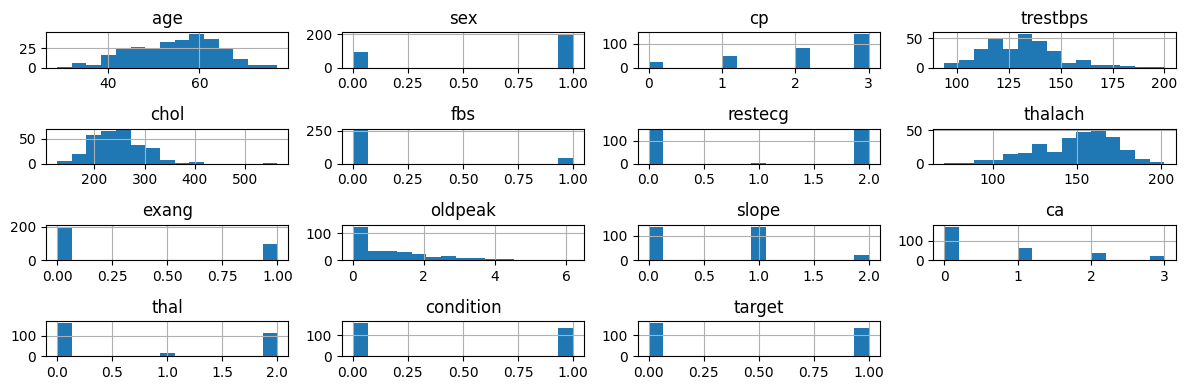

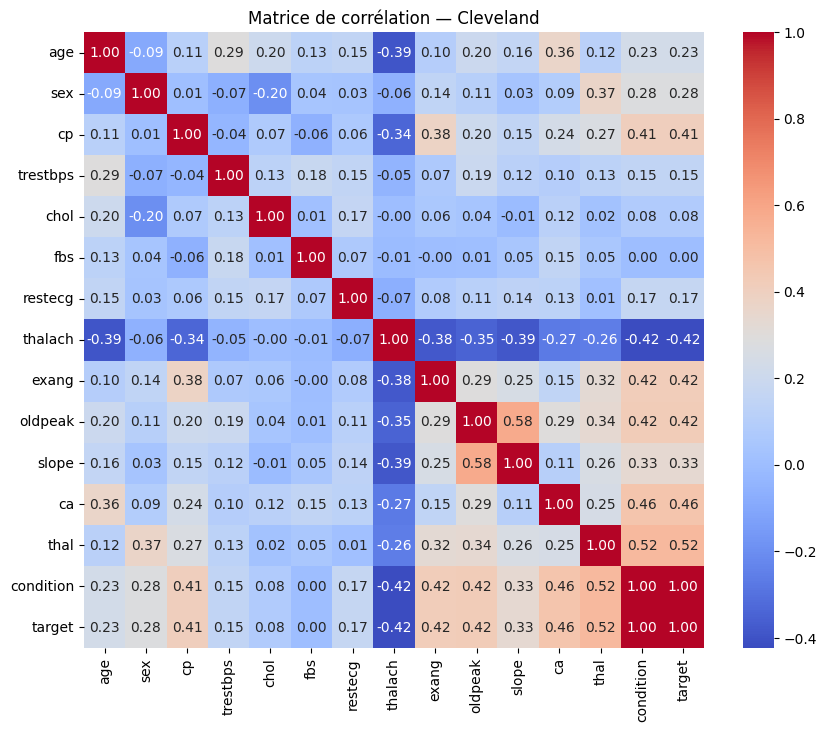

In [15]:
# Distribution de la variable cible
df['target'] = (df['condition'] > 0).astype(int)
print('Distribution cible :'); print(df['target'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['target'].value_counts().plot.bar(ax=axes[0], title='Distribution classes')
df.select_dtypes(include='number').hist(ax=axes[1], bins=15, figsize=(12,4))
plt.tight_layout(); plt.show()

# Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation — Cleveland'); plt.show()

## 🔧 Cellule 3 — Prétraitement Cleveland

In [16]:
df = pd.read_csv('heart_cleveland_upload.csv')
df['target'] = (df['condition'] > 0).astype(int)
df = df.drop(columns=['condition'])

# Valeurs manquantes → médiane
df.fillna(df.median(numeric_only=True), inplace=True)
print('Valeurs manquantes après imputation :', df.isnull().sum().sum())

# One-Hot Encoding
cat_cols = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
print('Dimensions après encodage :', df.shape)

X = df.drop(columns=['target']).values.astype(np.float32)
y = df['target'].values.astype(np.float32)

# Split 70/15/15 stratifié
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# StandardScaler fitté UNIQUEMENT sur le train
scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te  = scaler.transform(X_te)

print(f'Train : {len(X_tr)} | Val : {len(X_val)} | Test : {len(X_te)}')

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
X_tr_t, X_val_t, X_te_t = to_t(X_tr), to_t(X_val), to_t(X_te)
y_tr_t, y_val_t, y_te_t = to_t(y_tr), to_t(y_val), to_t(y_te)
N_FEAT = X_tr.shape[1]
print('✅ Prétraitement Cleveland terminé — nb features :', N_FEAT)

Valeurs manquantes après imputation : 0
Dimensions après encodage : (297, 23)
Train : 207 | Val : 45 | Test : 45
✅ Prétraitement Cleveland terminé — nb features : 22


## 🧠 Cellule 4 — Architecture MLP

In [17]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(0.3),

            nn.Linear(32, 1),  # logit brut → BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

mlp = MLP(N_FEAT).to(DEVICE)
print(mlp)
total_params = sum(p.numel() for p in mlp.parameters())
print(f'Total paramètres : {total_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total paramètres : 13,761


## 🏋️ Cellule 5 — Entraînement MLP

In [18]:
pos_w = torch.tensor([(y_tr == 0).sum() / (y_tr == 1).sum()]).to(DEVICE)
criterion_mlp = nn.BCEWithLogitsLoss(pos_weight=pos_w)
optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_mlp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_mlp, patience=5, factor=0.5)

best_val_loss = np.inf
patience_counter = 0
PATIENCE = 15
train_losses, val_losses = [], []

for epoch in range(1, 101):
    # ── Train ──
    mlp.train()
    idx = torch.randperm(len(y_tr_t))
    ep_loss = []
    for i in range(0, len(y_tr_t), 32):
        b = idx[i:i+32]
        xb, yb = X_tr_t[b].to(DEVICE), y_tr_t[b].to(DEVICE)
        optimizer_mlp.zero_grad()
        loss = criterion_mlp(mlp(xb), yb)
        loss.backward(); optimizer_mlp.step()
        ep_loss.append(loss.item())
    tr_loss = np.mean(ep_loss)

    # ── Validation ──
    mlp.eval()
    with torch.no_grad():
        va_loss = criterion_mlp(mlp(X_val_t.to(DEVICE)), y_val_t.to(DEVICE)).item()

    scheduler_mlp.step(va_loss)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | train={tr_loss:.4f} | val={va_loss:.4f}')

    if va_loss < best_val_loss - 1e-4:
        best_val_loss = va_loss
        patience_counter = 0
        torch.save(mlp.state_dict(), 'best_mlp.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping epoch {epoch}')
            break

print('✅ Entraînement terminé')

Epoch  10 | train=0.4534 | val=0.4220
Epoch  20 | train=0.3918 | val=0.3722
Epoch  30 | train=0.2877 | val=0.3716
Epoch  40 | train=0.2972 | val=0.3896
Early stopping epoch 43
✅ Entraînement terminé


## 📈 Cellule 6 — Évaluation MLP

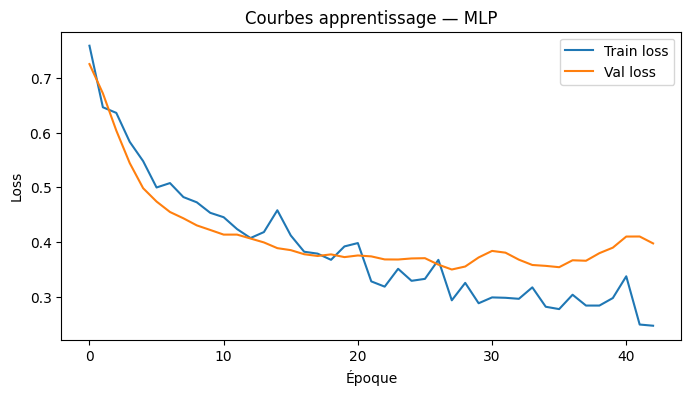

== TEST SET ==
              precision    recall  f1-score   support

        Sain       0.88      0.96      0.92        24
      Malade       0.95      0.86      0.90        21

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.91      0.91      0.91        45

AUC-ROC : 0.9077


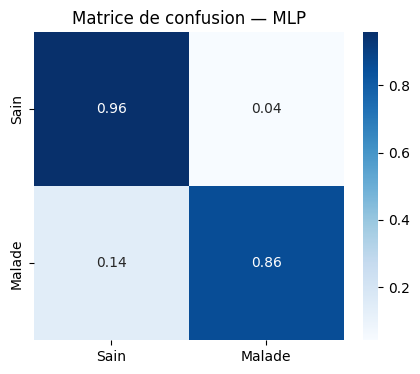

In [19]:
# Courbes d'apprentissage
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.title('Courbes apprentissage — MLP')
plt.xlabel('Époque'); plt.ylabel('Loss'); plt.legend(); plt.show()

# Évaluation finale sur le test set (UNE SEULE FOIS)
mlp.load_state_dict(torch.load('best_mlp.pt'))
mlp.eval()
with torch.no_grad():
    logits = mlp(X_te_t.to(DEVICE))
    preds  = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(int)

y_true = y_te_t.numpy().astype(int)
print('== TEST SET ==')
print(classification_report(y_true, preds, target_names=['Sain', 'Malade']))
print(f'AUC-ROC : {roc_auc_score(y_true, preds):.4f}')

# Matrice de confusion
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_true, preds, normalize='true'),
            annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Sain','Malade'], yticklabels=['Sain','Malade'])
plt.title('Matrice de confusion — MLP'); plt.show()

---
## 📊 Cellule 7 — Chargement MIT-BIH (CNN / RNN / LSTM / GRU / Hybride)

Train : (87554, 187) | Test : (21892, 187)
Distribution classes train : [72471  2223  5788   641  6431]


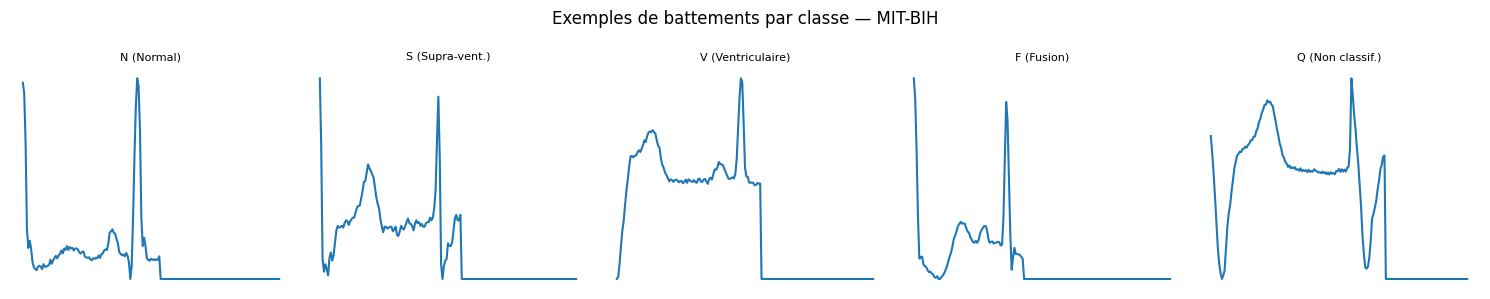

In [20]:
df_train = pd.read_csv('mitbih_train.csv', header=None)
df_test  = pd.read_csv('mitbih_test.csv',  header=None)

X_tr_m = df_train.iloc[:, :-1].values.astype(np.float32)
y_tr_m = df_train.iloc[:,  -1].values.astype(int)
X_te_m = df_test.iloc[:,  :-1].values.astype(np.float32)
y_te_m = df_test.iloc[:,   -1].values.astype(int)

print('Train :', X_tr_m.shape, '| Test :', X_te_m.shape)
print('Distribution classes train :', np.bincount(y_tr_m))

# Visualisation d'un exemple par classe
CLASSES = ['N (Normal)', 'S (Supra-vent.)', 'V (Ventriculaire)', 'F (Fusion)', 'Q (Non classif.)']
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for c in range(5):
    idx = np.where(y_tr_m == c)[0][0]
    axes[c].plot(X_tr_m[idx])
    axes[c].set_title(CLASSES[c], fontsize=8)
    axes[c].axis('off')
plt.suptitle('Exemples de battements par classe — MIT-BIH')
plt.tight_layout(); plt.show()

In [21]:
import os
print(os.listdir('/content/'))

['.config', 'heart_cleveland_upload.csv', 'sample_data', 'mitbih_test.csv', 'best_mlp.pt', 'mitbih_train.csv']


## 🔧 Cellule 8 — Prétraitement MIT-BIH

In [22]:
# Normalisation z-score par segment
def normalize(X):
    mu  = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mu) / std

X_tr_m = normalize(X_tr_m)
X_te_m = normalize(X_te_m)

# Split train → train + val
X_tr_m, X_val_m, y_tr_m, y_val_m = train_test_split(
    X_tr_m, y_tr_m, test_size=0.15, stratify=y_tr_m, random_state=SEED)

class MITBIHDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, 187)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# WeightedRandomSampler pour le déséquilibre
class_counts  = np.bincount(y_tr_m)
class_weights = 1.0 / (class_counts + 1e-8)
sample_weights = class_weights[y_tr_m]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

BS = 64
train_loader = DataLoader(MITBIHDataset(X_tr_m, y_tr_m), batch_size=BS, sampler=sampler)
val_loader   = DataLoader(MITBIHDataset(X_val_m, y_val_m), batch_size=BS, shuffle=False)
test_loader  = DataLoader(MITBIHDataset(X_te_m,  y_te_m),  batch_size=BS, shuffle=False)

# Poids pour la CrossEntropyLoss
loss_w = torch.tensor(class_weights / class_weights.sum() * 5, dtype=torch.float32).to(DEVICE)

print(f'Train : {len(train_loader.dataset):,} | Val : {len(val_loader.dataset):,} | Test : {len(test_loader.dataset):,}')
print('✅ DataLoaders prêts')

Train : 74,420 | Val : 13,134 | Test : 21,892
✅ DataLoaders prêts


## 🛠️ Cellule 9 — Fonctions utilitaires (train / eval / plots)

In [23]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

@torch.no_grad()
def eval_model(model, loader, criterion):
    model.eval()
    all_preds, all_labels, losses = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out  = model(xb)
        losses.append(criterion(out, yb).item())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    return np.mean(losses), np.array(all_preds), np.array(all_labels)

def fit(model, name, lr=1e-3, epochs=80, patience=10):
    """Boucle d'entraînement complète avec early stopping."""
    criterion = nn.CrossEntropyLoss(weight=loss_w)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    path = f'best_{name}.pt'

    best_loss, counter = np.inf, 0
    tr_losses, va_losses = [], []

    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, val_preds, val_labels = eval_model(model, val_loader, criterion)
        scheduler.step(va_loss)
        tr_losses.append(tr_loss); va_losses.append(va_loss)

        if epoch % 10 == 0:
            f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)
            print(f'  [{name}] Epoch {epoch:3d} | train={tr_loss:.4f} | val={va_loss:.4f} | F1={f1:.4f}')

        if va_loss < best_loss - 1e-4:
            best_loss = va_loss; counter = 0
            torch.save(model.state_dict(), path)
        else:
            counter += 1
            if counter >= patience:
                print(f'  Early stopping epoch {epoch}'); break

    # Test final
    model.load_state_dict(torch.load(path))
    _, preds, labels = eval_model(model, test_loader, criterion)

    # Courbes
    plt.figure(figsize=(8, 3))
    plt.plot(tr_losses, label='Train'); plt.plot(va_losses, label='Val')
    plt.title(f'Courbes apprentissage — {name}'); plt.legend(); plt.show()

    # Matrice de confusion
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(labels, preds, normalize='true'),
                annot=True, fmt='.2f', cmap='Blues',
                xticklabels=['N','S','V','F','Q'], yticklabels=['N','S','V','F','Q'])
    plt.title(f'Matrice de confusion — {name}'); plt.show()

    print(f'\n== TEST — {name} ==')
    print(classification_report(labels, preds, target_names=['N','S','V','F','Q'], zero_division=0))
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    return model, acc, f1

print('✅ Fonctions utilitaires chargées')

✅ Fonctions utilitaires chargées


## 🧠 Cellule 10 — CNN 1D

CNN — paramètres : 168,325
  [CNN] Epoch  10 | train=0.0253 | val=0.8332 | F1=0.4847
  [CNN] Epoch  20 | train=0.0083 | val=0.3818 | F1=0.6564
  [CNN] Epoch  30 | train=0.0065 | val=0.3240 | F1=0.6786
  [CNN] Epoch  40 | train=0.0021 | val=0.2869 | F1=0.7993
  [CNN] Epoch  50 | train=0.0019 | val=0.3299 | F1=0.8287
  Early stopping epoch 56


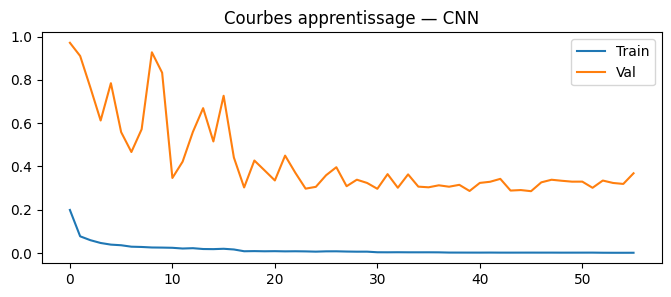

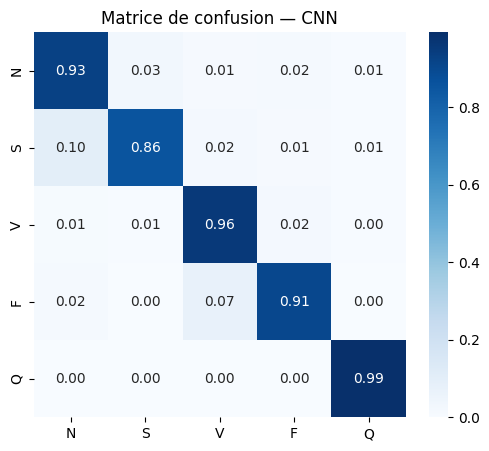


== TEST — CNN ==
              precision    recall  f1-score   support

           N       1.00      0.93      0.96     18118
           S       0.44      0.86      0.58       556
           V       0.84      0.96      0.90      1448
           F       0.28      0.91      0.43       162
           Q       0.92      0.99      0.96      1608

    accuracy                           0.93     21892
   macro avg       0.70      0.93      0.76     21892
weighted avg       0.96      0.93      0.94     21892



In [24]:
class CNN1D(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        def block(in_ch, out_ch, k):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=k//2),
                nn.BatchNorm1d(out_ch), nn.ReLU(), nn.MaxPool1d(2))
        self.features = nn.Sequential(
            block(1,   32, 7),
            block(32,  64, 5),
            block(64, 128, 3),
            nn.Conv1d(128, 256, 3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

cnn_model = CNN1D().to(DEVICE)
print(f'CNN — paramètres : {sum(p.numel() for p in cnn_model.parameters()):,}')
cnn_model, cnn_acc, cnn_f1 = fit(cnn_model, 'CNN', lr=1e-3, epochs=80, patience=10)

## 🧠 Cellule 11 — RNN Simple

RNN — paramètres : 149,125
  [RNN] Epoch  10 | train=0.5965 | val=1.9454 | F1=0.1894
  Early stopping epoch 18


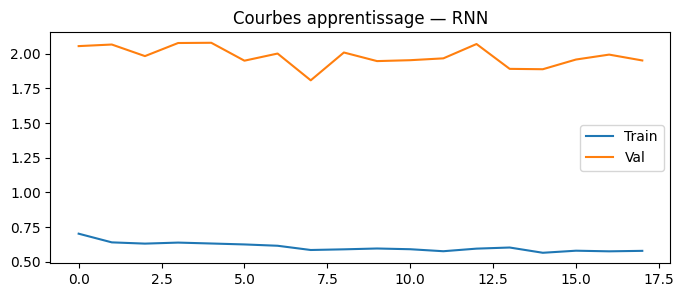

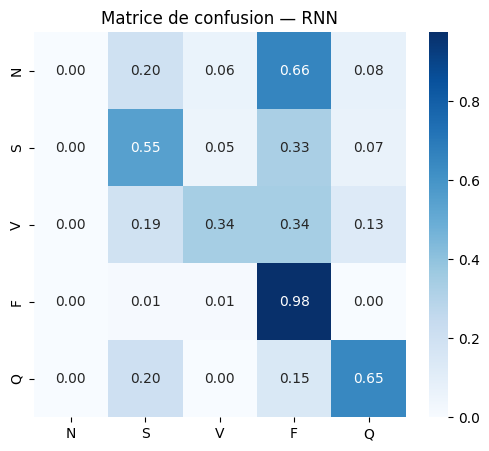


== TEST — RNN ==
              precision    recall  f1-score   support

           N       0.00      0.00      0.00     18118
           S       0.07      0.55      0.12       556
           V       0.29      0.34      0.31      1448
           F       0.01      0.98      0.02       162
           Q       0.39      0.65      0.48      1608

    accuracy                           0.09     21892
   macro avg       0.15      0.50      0.19     21892
weighted avg       0.05      0.09      0.06     21892



In [25]:
class RNNModel(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.rnn = nn.RNN(1, 128, num_layers=2, batch_first=True,
                          dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x):
        out, _ = self.rnn(x.permute(0, 2, 1))
        return self.classifier(out[:, -1, :])

rnn_model = RNNModel().to(DEVICE)
print(f'RNN — paramètres : {sum(p.numel() for p in rnn_model.parameters()):,}')
rnn_model, rnn_acc, rnn_f1 = fit(rnn_model, 'RNN', lr=1e-3, epochs=80, patience=10)

## 🧠 Cellule 12 — LSTM

LSTM — paramètres : 546,181
  [LSTM] Epoch  10 | train=0.2672 | val=1.2761 | F1=0.2161
  [LSTM] Epoch  20 | train=0.1761 | val=1.1226 | F1=0.2501
  [LSTM] Epoch  30 | train=0.1158 | val=0.9015 | F1=0.2960
  [LSTM] Epoch  40 | train=0.0771 | val=0.7137 | F1=0.3702
  [LSTM] Epoch  50 | train=0.0625 | val=0.5880 | F1=0.4736
  [LSTM] Epoch  60 | train=0.0501 | val=0.5332 | F1=0.4786
  Early stopping epoch 69


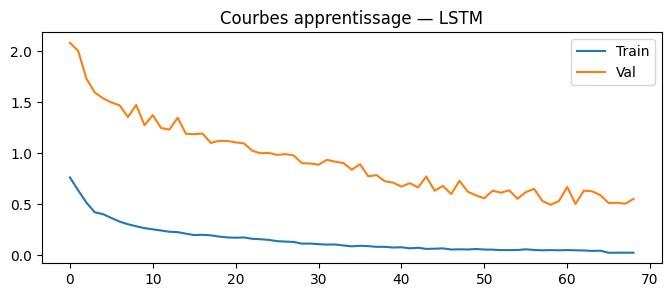

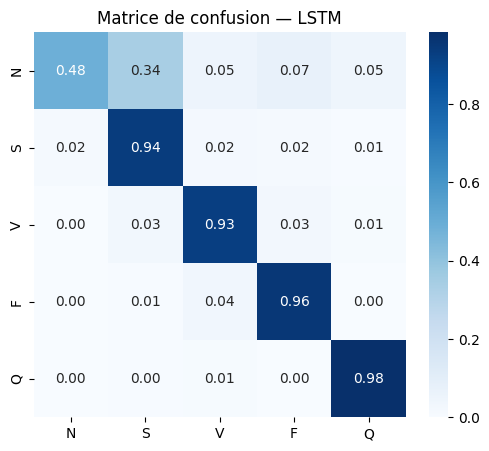


== TEST — LSTM ==
              precision    recall  f1-score   support

           N       1.00      0.48      0.65     18118
           S       0.08      0.94      0.14       556
           V       0.58      0.93      0.71      1448
           F       0.10      0.96      0.18       162
           Q       0.64      0.98      0.77      1608

    accuracy                           0.57     21892
   macro avg       0.48      0.86      0.49     21892
weighted avg       0.91      0.57      0.65     21892



In [26]:
class LSTMModel(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.lstm = nn.LSTM(1, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x.permute(0, 2, 1))
        return self.classifier(out[:, -1, :])

lstm_model = LSTMModel().to(DEVICE)
print(f'LSTM — paramètres : {sum(p.numel() for p in lstm_model.parameters()):,}')
lstm_model, lstm_acc, lstm_f1 = fit(lstm_model, 'LSTM', lr=1e-3, epochs=80, patience=10)

## 🧠 Cellule 13 — GRU

GRU — paramètres : 413,829
  [GRU] Epoch  10 | train=0.0634 | val=0.8192 | F1=0.3506
  [GRU] Epoch  20 | train=0.0332 | val=0.5446 | F1=0.5095
  Early stopping epoch 27


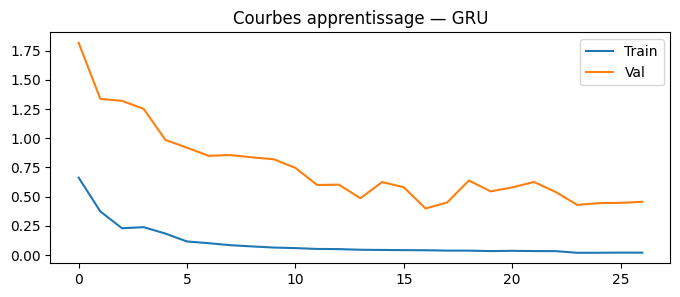

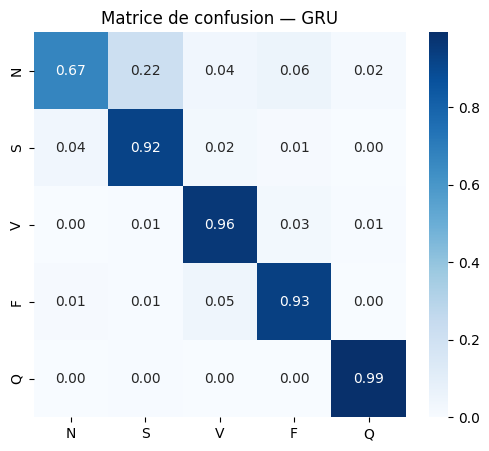


== TEST — GRU ==
              precision    recall  f1-score   support

           N       1.00      0.67      0.80     18118
           S       0.11      0.92      0.20       556
           V       0.66      0.96      0.78      1448
           F       0.13      0.93      0.22       162
           Q       0.82      0.99      0.90      1608

    accuracy                           0.72     21892
   macro avg       0.54      0.90      0.58     21892
weighted avg       0.93      0.72      0.79     21892



In [27]:
class GRUModel(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.gru = nn.GRU(1, 128, num_layers=2, batch_first=True,
                          dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x):
        out, _ = self.gru(x.permute(0, 2, 1))
        return self.classifier(out[:, -1, :])

gru_model = GRUModel().to(DEVICE)
print(f'GRU — paramètres : {sum(p.numel() for p in gru_model.parameters()):,}')
gru_model, gru_acc, gru_f1 = fit(gru_model, 'GRU', lr=1e-3, epochs=80, patience=10)

## 🧠 Cellule 14 — Architecture Hybride CNN + LSTM

CNN+LSTM — paramètres : 633,989
  [hybrid] Epoch  10 | train=0.0474 | val=0.5966 | F1=0.4646
  [hybrid] Epoch  20 | train=0.0298 | val=0.4497 | F1=0.5527
  [hybrid] Epoch  30 | train=0.0239 | val=0.4089 | F1=0.6166
  [hybrid] Epoch  40 | train=0.0215 | val=0.3997 | F1=0.6023
  [hybrid] Epoch  50 | train=0.0120 | val=0.3640 | F1=0.6677
  [hybrid] Epoch  60 | train=0.0080 | val=0.3517 | F1=0.7175
  [hybrid] Epoch  70 | train=0.0054 | val=0.3320 | F1=0.7433
  [hybrid] Epoch  80 | train=0.0049 | val=0.3314 | F1=0.7649
  Early stopping epoch 84


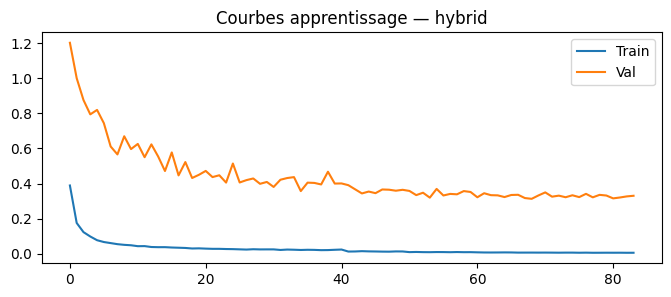

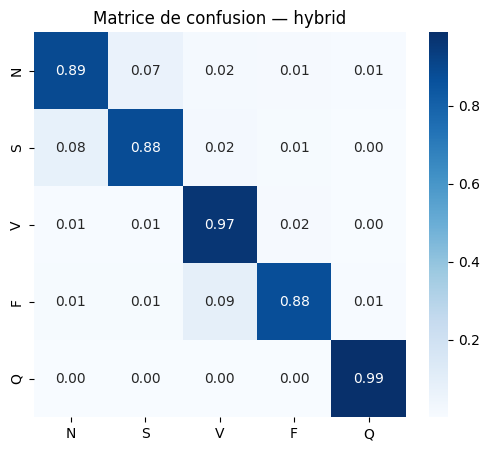


== TEST — hybrid ==
              precision    recall  f1-score   support

           N       1.00      0.89      0.94     18118
           S       0.28      0.88      0.43       556
           V       0.78      0.97      0.86      1448
           F       0.35      0.88      0.50       162
           Q       0.92      0.99      0.95      1608

    accuracy                           0.90     21892
   macro avg       0.66      0.92      0.74     21892
weighted avg       0.95      0.90      0.92     21892



In [28]:
class CNNLSTMHybrid(nn.Module):
    N_SEG, SEG_L = 11, 17  # 11 segments de 17 points = 187

    def __init__(self, n_classes=5):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.35),
            nn.Linear(128, n_classes))

    def forward(self, x):
        B = x.size(0)
        segs = x[:, :, :self.N_SEG * self.SEG_L].view(B, self.N_SEG, self.SEG_L)
        segs = segs.unsqueeze(2).view(B * self.N_SEG, 1, self.SEG_L)
        feat = self.cnn(segs).squeeze(-1).view(B, self.N_SEG, 64)
        out, _ = self.lstm(feat)
        return self.classifier(out[:, -1, :])

hybrid_model = CNNLSTMHybrid().to(DEVICE)
print(f'CNN+LSTM — paramètres : {sum(p.numel() for p in hybrid_model.parameters()):,}')
hybrid_model, hyb_acc, hyb_f1 = fit(hybrid_model, 'hybrid', lr=5e-4, epochs=100, patience=15)

## 📊 Cellule 15 — Comparaison finale des modèles


  COMPARAISON FINALE (MIT-BIH test set)
  Modèle         Accuracy   Macro F1
  ----------------------------------
  CNN 1D           0.9334     0.7648
  RNN              0.0911     0.1882
  LSTM             0.5658     0.4927
  GRU              0.7196     0.5815
  CNN+LSTM         0.9028     0.7355


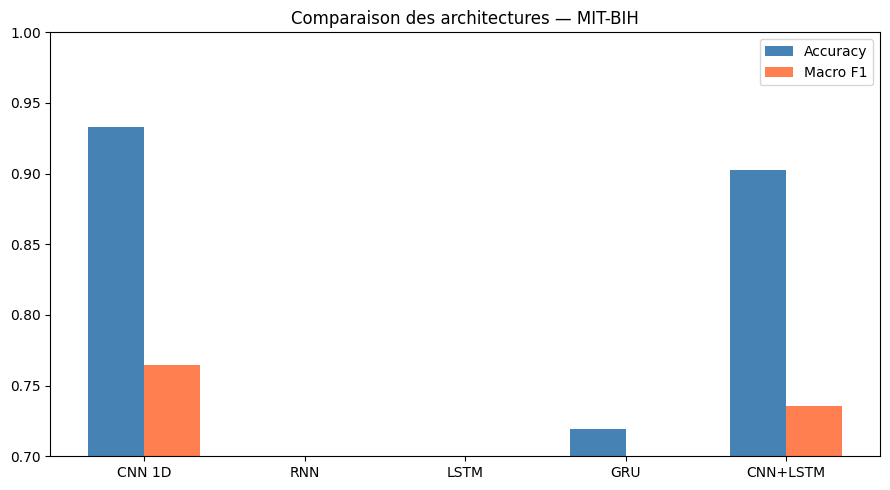


✅ Projet terminé !


In [29]:
results = {
    'CNN 1D' : (cnn_acc,  cnn_f1),
    'RNN'    : (rnn_acc,  rnn_f1),
    'LSTM'   : (lstm_acc, lstm_f1),
    'GRU'    : (gru_acc,  gru_f1),
    'CNN+LSTM': (hyb_acc, hyb_f1),
}

print('\n' + '='*50)
print('  COMPARAISON FINALE (MIT-BIH test set)')
print('='*50)
print(f"  {'Modèle':<12} {'Accuracy':>10} {'Macro F1':>10}")
print('  ' + '-'*34)
for name, (acc, f1) in results.items():
    print(f'  {name:<12} {acc:>10.4f} {f1:>10.4f}')

# Bar chart
models = list(results.keys())
accs = [results[m][0] for m in models]
f1s  = [results[m][1] for m in models]

x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
ax.bar(x + w/2, f1s,  w, label='Macro F1',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.0)
ax.set_title('Comparaison des architectures — MIT-BIH')
ax.legend(); plt.tight_layout(); plt.show()

print('\n✅ Projet terminé !')